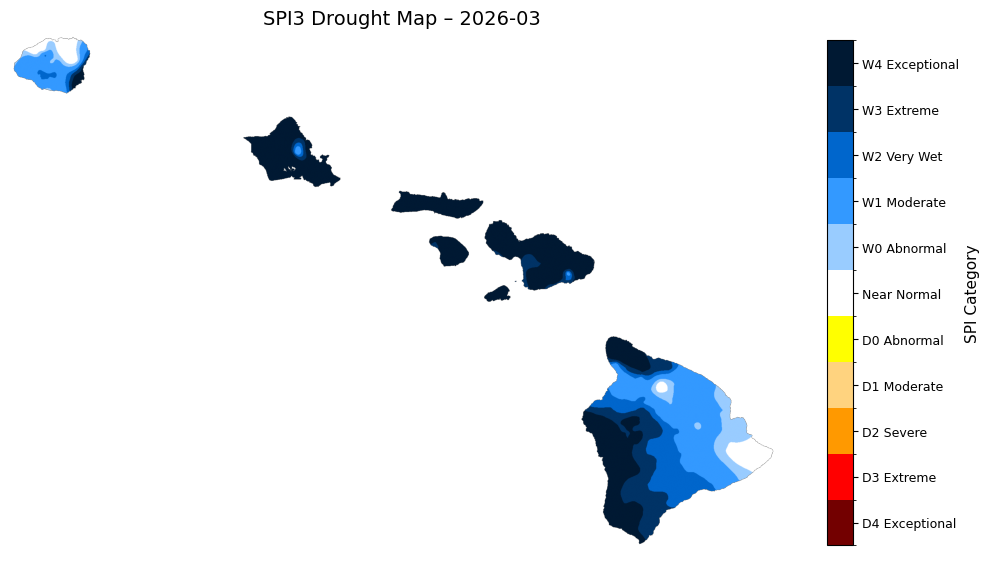

In [3]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

year = 2026
month = 3

local_dep_dir = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/scripts/data/dependencies"
spi_file = os.path.join(local_dep_dir, "spi3", f"spi3_{year}_{month:02d}.tif")
output_dir = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/public"
outfile = os.path.join(output_dir, f"spi3_cat.tif")

with rasterio.open(spi_file) as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

# 1. Prepare categorical array
# Use 255 for NoData to keep it separate from our 0-10 categories
categorical = np.full_like(data, 255, dtype=np.uint8)

# 2. Define masks for valid data (ignoring NoData)
valid_mask = (data != nodata) & (~np.isnan(data))

# 3. Categorize (Fixed Logic)
# Using a clean progression: <= -2, (-2, -1.6], (-1.6, -1.3], etc.
categorical[valid_mask & (data <= -2.0)] = 0                               # D4
categorical[valid_mask & (data > -2.0) & (data <= -1.6)] = 1               # D3
categorical[valid_mask & (data > -1.6) & (data <= -1.3)] = 2               # D2
categorical[valid_mask & (data > -1.3) & (data <= -0.8)] = 3               # D1
categorical[valid_mask & (data > -0.8) & (data <= -0.5)] = 4               # D0
categorical[valid_mask & (data > -0.5) & (data < 0.5)] = 5                 # Normal
categorical[valid_mask & (data >= 0.5) & (data < 0.8)] = 6                 # W0
categorical[valid_mask & (data >= 0.8) & (data < 1.3)] = 7                 # W1
categorical[valid_mask & (data >= 1.3) & (data < 1.6)] = 8                 # W2
categorical[valid_mask & (data >= 1.6) & (data < 2.0)] = 9                 # W3
categorical[valid_mask & (data >= 2.0)] = 10                               # W4

# 4. Save the categorical GeoTIFF
profile.update(dtype=rasterio.uint8, count=1, nodata=255)
with rasterio.open(outfile, 'w', **profile) as dst:
    dst.write(categorical.astype(rasterio.uint8), 1)

# 5. Visualization
colors = [
    "#730000", "#FF0000", "#FF9900", "#FFD37F", "#FFFF00", # Drought
    "#FFFFFF",                                             # Normal
    "#99CCFF", "#3399FF", "#0066CC", "#003366", "#001933"  # Wet
]

labels = [
    "D4 Exceptional", "D3 Extreme", "D2 Severe", "D1 Moderate", "D0 Abnormal",
    "Near Normal",
    "W0 Abnormal", "W1 Moderate", "W2 Very Wet", "W3 Extreme", "W4 Exceptional"
]

# Create a masked version for plotting so NoData (255) is transparent
plot_data = np.ma.masked_where(categorical == 255, categorical)

cmap = ListedColormap(colors)
# Boundaries should be at half-steps to center the colors on integer values 0-10
norm = BoundaryNorm(np.arange(-0.5, 11.5, 1), len(colors))

plt.figure(figsize=(10, 7))
im = plt.imshow(plot_data, cmap=cmap, norm=norm)
plt.title(f"SPI3 Drought Map – {year}-{month:02d}", fontsize=14)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("SPI Category", fontsize=11)

plt.tight_layout()
plt.show()

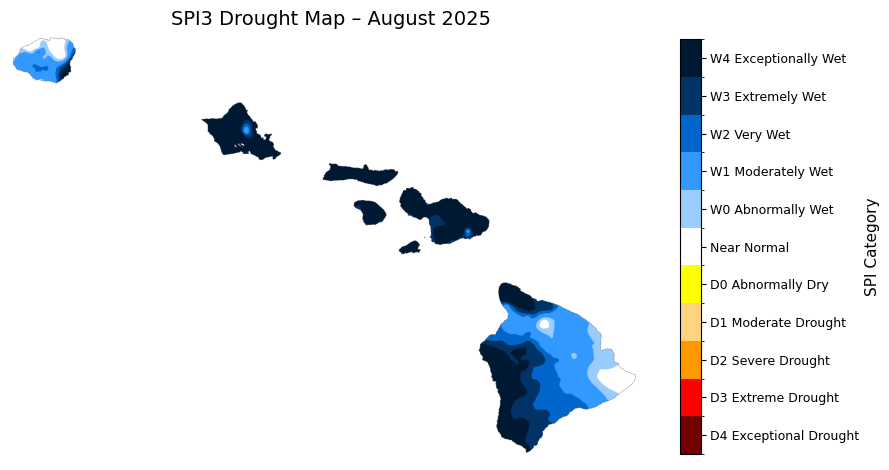

In [20]:
import os
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd

# --- Configuration ---
raster_folder = "/Users/cherryleheu/Documents/HCDP/Data/monthly/drought_category"
# Using the coastline/statewide boundary
shapefile = "../public/shapefiles/Coastline.shp"
out_csv = "../public/spi/statewide_spi3_category_stats.csv"

# Mapping for column names to match your visualization
cat_map = {
    0: "D4", 1: "D3", 2: "D2", 3: "D1", 4: "D0",
    5: "Near Normal",
    6: "W0", 7: "W1", 8: "W2", 9: "W3", 10: "W4"
}

def get_statewide_spi_stats():
    print("--- Processing Statewide SPI Categories ---")
    
    # Load and dissolve to get a single statewide geometry
    gdf = gpd.read_file(shapefile)
    # Dissolve everything into one feature to represent the whole state
    gdf_statewide = gdf.dissolve() 

    records = []

    # Time loop: Sep 2024 to Aug 2025
    for year in [2024, 2025]:
        for month in range(1, 13):
            if year == 2024 and month < 9: continue
            if year == 2025 and month > 8: break

            tif_path = os.path.join(raster_folder, f"spi3_{year}_{month:02d}_category.tif")
            
            if not os.path.exists(tif_path):
                print(f"Skipping: {tif_path} (File not found)")
                continue

            with rasterio.open(tif_path) as src:
                # Read data; use masking to handle nodata automatically
                data = src.read(1, masked=True)
                
                # 'data.mask' identifies nodata/ocean pixels
                # We only want to calculate percentages based on valid land pixels
                valid_pixel_count = data.count() 
                
                record = {
                    "year": year,
                    "month": month,
                    "date": f"{year}-{month:02d}",
                    "division_full": "Statewide"
                }

                # Count occurrences for each category 0-10
                for val, code in cat_map.items():
                    # Count where pixel equals current category value
                    cat_count = np.sum(data == val)
                    pct = (cat_count / valid_pixel_count) * 100 if valid_pixel_count > 0 else 0
                    record[code] = pct
                
                records.append(record)

    # --- Create DataFrame and Organize ---
    df = pd.DataFrame(records)
    
    # Define column order: Info columns first, then D4 through W4
    cols = ["year", "month", "date", "division_full"] + list(cat_map.values())
    df = df[cols].sort_values(["year", "month"])

    # Export
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    df[df["date"] == "2025-08"].to_csv(out_csv, index=False)
    
    print(df[df["date"] == "2025-08"].head())
    print(f"\nSuccessfully saved statewide stats to: {out_csv}")

get_statewide_spi_stats()

--- Processing Statewide SPI Categories ---
    year  month     date division_full        D4        D3         D2  \
11  2025      8  2025-08     Statewide  2.268537  7.681009  11.046485   

           D1         D0  Near Normal        W0        W1        W2        W3  \
11  28.665581  17.310744     29.69585  1.866082  0.824007  0.269113  0.164246   

          W4  
11  0.208346  

Successfully saved statewide stats to: ../public/spi/statewide_spi3_category_stats.csv


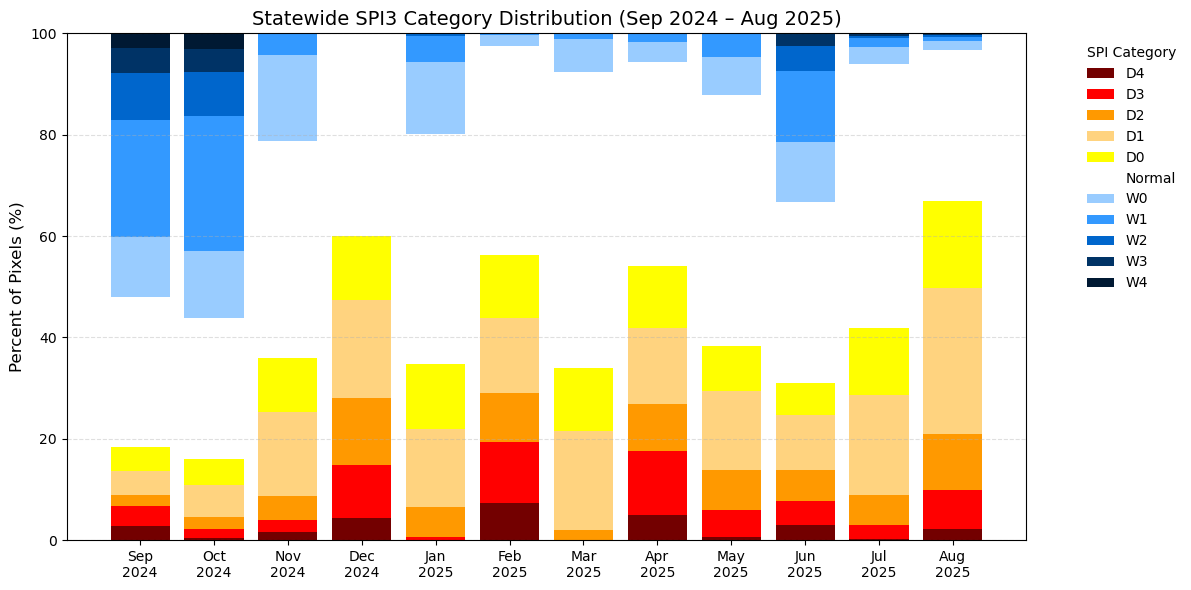

In [ ]:
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

raster_folder = "/Users/cherryleheu/Documents/HCDP/Data/monthly/drought_category"
shapefile = "../public/shapefiles/Coastline.shp"

gdf = gpd.read_file(shapefile)
gdf_statewide = gdf.dissolve()

categories = list(range(11))
labels = [
    "D4", "D3", "D2", "D1", "D0",
    "Normal",
    "W0", "W1", "W2", "W3", "W4"
]
colors = [
    "#730000", "#FF0000", "#FF9900", "#FFD37F", "#FFFF00",
    "#FFFFFF",
    "#99CCFF", "#3399FF", "#0066CC", "#003366", "#001933"
]

records = []

for year in [2024, 2025]:
    for month in range(1, 13):
        if year == 2024 and month < 9:
            continue
        if year == 2025 and month > 8:
            break

        tif_path = f"{raster_folder}/spi3_{year}_{month:02d}_category.tif"
        if not os.path.exists(tif_path):
            print(f"Missing file: {tif_path}")
            continue

        with rasterio.open(tif_path) as src:
            data = src.read(1).astype(float)
            nodata = src.nodata

        data = np.where(data == nodata, np.nan, data)
        valid = np.isfinite(data)
        total_pixels = np.sum(valid)

        percentages = []
        for cat in categories:
            count = np.sum(data == cat)
            pct = (count / total_pixels) * 100 if total_pixels > 0 else np.nan
            percentages.append(pct)

        records.append({
            "year": year,
            "month": month,
            **{f"cat_{cat}": percentages[cat] for cat in categories}
        })

df = pd.DataFrame(records)
df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))
df = df.sort_values("date").reset_index(drop=True)

df_plot = df[[f"cat_{c}" for c in categories]]
dates = df["date"].dt.strftime("%b\n%Y")

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(df_plot))
for i, cat in enumerate(categories):
    ax.bar(
        dates,
        df_plot[f"cat_{cat}"],
        bottom=bottom,
        color=colors[i],
        label=labels[i],
        width=0.8
    )
    bottom += df_plot[f"cat_{cat}"]

ax.set_ylabel("Percent of Pixels (%)", fontsize=12)
ax.set_title("Statewide SPI3 Category Distribution (Sep 2024 – Aug 2025)", fontsize=14)
ax.legend(
    title="SPI Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [13]:
import os
import glob
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd
from rasterstats import zonal_stats

def get_spi_category_stats(division="climate_divisions"):
    """
    Compute percentage of pixels in each SPI category (0–10)
    for each feature in a division shapefile, across all months
    from 2024-09 through 2025-08.
    """
    print(f"\n--- Processing {division} (SPI Categories) ---")

    cat_map = {
        0: "D4", 1: "D3", 2: "D2", 3: "D1", 4: "D0",
        5: "Near Normal",
        6: "W0", 7: "W1", 8: "W2", 9: "W3", 10: "W4"
    }

    # --- Paths ---
    shapefile = f"../public/shapefiles/{division}.shp"
    raster_folder = "/Users/cherryleheu/Documents/HCDP/Data/monthly/drought_category/"
    out_csv = f"../public/spi/{division}_spi3_category_stats.csv"

    # --- Load shapefile ---
    gdf = gpd.read_file(shapefile).copy()
    island_col = next(
        (c for c in gdf.columns if c.lower() in ["island", "mokupuni", "isle", "islandname"]),
        None
    )
    name_col = next(
        (c for c in gdf.columns if c.lower() in ["name", "division", "moku", "climate_div", "ahupuaa", "county"]),
        None
    )

    # --- Build division_full name like "Hawaiʻi::Hilo" ---
    if island_col and name_col:
        gdf["division_full"] = gdf[island_col].astype(str) + "::" + gdf[name_col].astype(str)
        gdf = gdf.dissolve(by="division_full", as_index=False)
    elif name_col:
        gdf["division_full"] = gdf[name_col].astype(str)
        gdf = gdf.dissolve(by="division_full", as_index=False)
    else:
        raise ValueError("No valid island or name column found in shapefile.")

    # --- Category indices (0–10) ---
    categories = list(range(11))

    # --- Gather stats for each month ---
    all_records = []

    for year in [2024, 2025]:
        for month in range(1, 13):
            if year == 2024 and month < 9:
                continue
            if year == 2025 and month > 8:
                break

            tif_path = os.path.join(raster_folder, f"spi3_{year}_{month:02d}_category.tif")
            if not os.path.exists(tif_path):
                print(f"Missing file: {tif_path}")
                continue

            with rasterio.open(tif_path) as src:
                nodata = src.nodata

            zs = zonal_stats(gdf, tif_path, categorical=True, nodata=nodata)

            for i, stats in enumerate(zs):
                division_name = gdf.iloc[i]["division_full"]
                total = sum(stats.values())
                        
                record = {
                    "year": year,
                    "month": month,
                    "date": f"{year}-{month:02d}",
                    "division_full": division_name,
                }
                        
                # Apply the mapping to column names
                for val, code in cat_map.items():
                    count = stats.get(val, 0)
                    pct = (count / total) * 100 if total > 0 else np.nan
                    record[code] = pct  # Using "D4", "D3", etc. as the key
                        
                all_records.append(record)

    # --- Combine and export ---
    df = pd.DataFrame(all_records)
    df = df.sort_values(["division_full", "year", "month"])
    df[df["date"] == "2025-08"].to_csv(out_csv, index=False)
    print(df[df["date"] == "2025-08"].head())
    print(f"Saved SPI category stats → {out_csv}")


In [15]:
get_spi_category_stats("island")
get_spi_category_stats("climate")
get_spi_category_stats("moku")
get_spi_category_stats("ahupuaa")
get_spi_category_stats("watershed")


--- Processing island (SPI Categories) ---
    year  month     date division_full         D4         D3         D2  \
77  2025      8  2025-08       Hawai‘i   0.060105   3.892924   5.525225   
78  2025      8  2025-08    Kaho‘olawe   0.000000   0.000000   0.000000   
79  2025      8  2025-08        Kaua‘i   0.144447   9.322663  20.238142   
80  2025      8  2025-08        Lāna‘i   0.000000   0.000000  25.433962   
81  2025      8  2025-08          Maui  11.899560  21.120522  16.966450   

           D1         D0  Near Normal        W0        W1        W2        W3  \
77  23.719287  19.994991    42.381946  2.717533  0.988396  0.172524  0.213151   
78  18.619154  51.893096    29.487751  0.000000  0.000000  0.000000  0.000000   
79  44.485653  13.866875     6.332227  1.280500  2.162795  1.815343  0.351357   
80  74.566038   0.000000     0.000000  0.000000  0.000000  0.000000  0.000000   
81  31.520666  11.504504     6.988298  0.000000  0.000000  0.000000  0.000000   

          W4  
77 

In [28]:
get_spi_category_stats("climate")
get_spi_category_stats("moku")
get_spi_category_stats("ahupuaa")
get_spi_category_stats("watershed")


--- Processing climate (SPI Categories) ---
Saved SPI category stats → ../public/climate_spi3_category_stats.csv

--- Processing moku (SPI Categories) ---
Saved SPI category stats → ../public/moku_spi3_category_stats.csv

--- Processing ahupuaa (SPI Categories) ---
Saved SPI category stats → ../public/ahupuaa_spi3_category_stats.csv

--- Processing watershed (SPI Categories) ---
Saved SPI category stats → ../public/watershed_spi3_category_stats.csv
